In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [3]:
X

array([[-2.66849277,  2.75879612],
       [-0.46913009,  6.1913978 ],
       [-1.45819609,  7.44890585],
       ...,
       [-1.38459152,  5.39782309],
       [-9.77093537, -3.27201049],
       [-2.66463558,  1.54895913]], shape=(1000, 2))

In [4]:
y

array([1, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1,
       2, 2, 2, 1, 2, 2, 0, 2, 2, 1, 1, 1, 0, 0, 1, 2, 2, 2, 2, 1, 2, 0,
       1, 2, 0, 0, 0, 0, 2, 2, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2,
       2, 1, 0, 1, 1, 1, 0, 0, 0, 2, 2, 1, 2, 0, 0, 2, 0, 1, 0, 2, 1, 1,
       0, 1, 2, 2, 2, 0, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 2, 1, 2, 2, 1,
       1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 0, 2, 0, 1, 0, 0, 0, 1, 2, 1, 2, 0,
       0, 2, 0, 1, 0, 2, 1, 1, 0, 2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2,
       2, 2, 0, 2, 1, 0, 2, 1, 0, 2, 0, 0, 2, 2, 0, 0, 0, 1, 0, 0, 0, 2,
       2, 2, 1, 2, 1, 0, 2, 2, 1, 1, 2, 2, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 2, 0, 1, 1, 2, 0, 2, 0, 0, 2, 1, 1, 0, 0, 1, 2, 0, 1, 0,
       0, 0, 2, 0, 2, 0, 1, 1, 2, 1, 0, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 0,
       2, 2, 1, 0, 0, 2, 1, 1, 0, 0, 2, 0, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2,
       1, 2, 0, 2, 2, 0, 1, 2, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 0, 2,
       0, 0, 1, 2, 0, 0, 2, 0, 0, 0, 2, 2, 1, 2, 0,

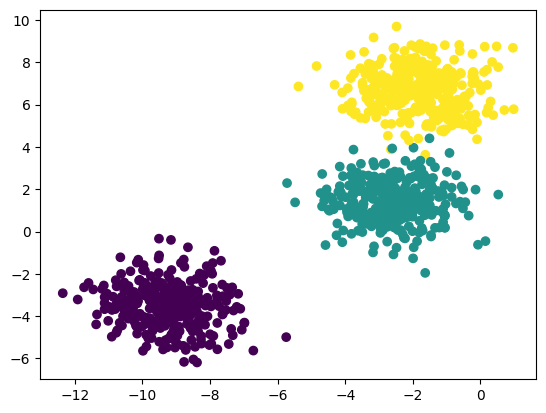

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.33, random_state=42)

In [8]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
#Elbow method
wcss = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

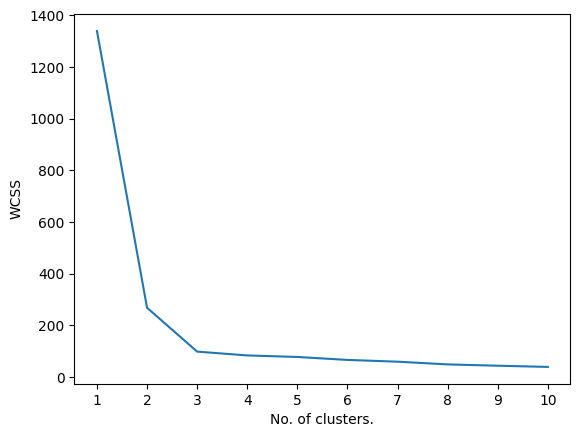

In [11]:
# Plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("No. of clusters.")
plt.ylabel("WCSS")
plt.show()

In [12]:
# there is an elbow at k=3

In [13]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [14]:
kmeans.fit_predict(X_train_scaled)

array([2, 1, 1, 2, 2, 0, 2, 0, 0, 1, 2, 2, 1, 1, 1, 1, 0, 1, 0, 0, 1, 2,
       1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 0, 1, 1,
       0, 2, 2, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 0, 0, 0,
       0, 0, 1, 0, 0, 2, 0, 1, 0, 2, 0, 0, 0, 2, 1, 0, 0, 2, 1, 2, 0, 0,
       2, 2, 1, 0, 0, 0, 2, 0, 2, 2, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 1, 1,
       1, 2, 0, 2, 1, 2, 0, 0, 1, 2, 1, 1, 0, 0, 2, 1, 0, 0, 2, 0, 1, 2,
       2, 0, 1, 2, 1, 1, 2, 1, 0, 0, 0, 2, 2, 1, 2, 2, 0, 2, 2, 0, 1, 2,
       2, 1, 0, 0, 0, 2, 0, 0, 1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 2, 2, 2, 1, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2,
       1, 1, 2, 1, 1, 1, 2, 1, 0, 0, 0, 1, 1, 0, 1, 0, 2, 2, 0, 0, 2, 1,
       0, 2, 1, 0, 2, 0, 0, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 1, 0, 1, 2, 0, 2, 0, 1, 2, 2, 0, 0, 1, 2, 1, 1,
       0, 0, 1, 2, 2, 1, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 2, 1, 2, 1, 1, 2,
       1, 2, 0, 0, 1, 0, 0, 2, 1, 2, 1, 1, 2, 1, 2,

In [15]:
y_pred = kmeans.predict(X_test_scaled)

In [16]:
y_pred

array([2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 0, 2, 1,
       2, 1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 1, 2, 2, 0, 2, 1, 2, 2, 0, 2, 1,
       0, 2, 2, 1, 2, 0, 0, 1, 0, 2, 0, 0, 1, 1, 1, 1, 0, 1, 2, 1, 0, 2,
       1, 1, 2, 0, 0, 2, 2, 1, 0, 0, 2, 0, 1, 1, 2, 0, 0, 2, 0, 1, 1, 2,
       1, 2, 2, 1, 0, 2, 2, 0, 2, 1, 2, 0, 2, 0, 0, 2, 1, 2, 0, 0, 1, 1,
       2, 0, 1, 2, 2, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 0, 0, 1, 0, 1, 2, 0,
       0, 0, 0, 2, 1, 2, 2, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 1, 2, 0, 1,
       1, 2, 0, 1, 0, 0, 2, 0, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 0, 2,
       0, 2, 1, 2, 0, 0, 2, 0, 2, 0, 1, 2, 0, 1, 2, 0, 1, 1, 1, 2, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 1,
       1, 2, 1, 1, 0, 0, 2, 0, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 0, 2,
       1, 0, 0, 2, 2, 2, 1, 1, 1, 2, 2, 1, 0, 0, 0, 1, 0, 0, 1, 2, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2, 2, 2, 1, 2, 1,
       0, 2, 2, 1, 1, 2, 2, 1, 0, 0, 0, 1, 2, 0, 1,

In [17]:
X_test.shape

(330, 2)

In [18]:
y_pred.shape

(330,)

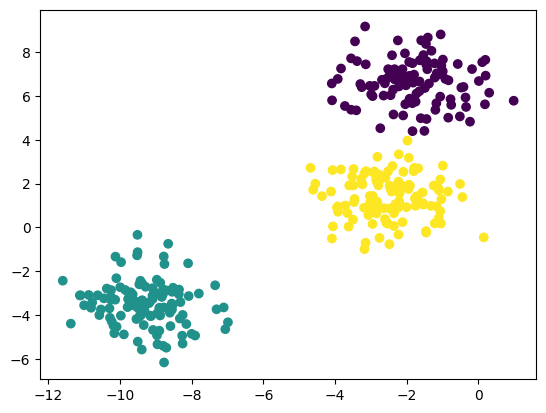

In [19]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [21]:
# Vakudating the k value
# Knee locater
# SIlhouette scoring 

In [22]:
!pip install kneed

In [23]:
#knee locator
from kneed import KneeLocator

In [24]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [25]:
kl.elbow

np.int64(3)

In [26]:
#Silhouette scoring
from sklearn.metrics import silhouette_score

In [27]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [28]:
silhouette_coefficients

[0.7144987135400431,
 0.6755945308615585,
 0.5735467450653599,
 0.4424037046060218,
 0.35794535095262514,
 0.407609091052316,
 0.3455270292729625,
 0.3344775054540552,
 0.3332370543069856]

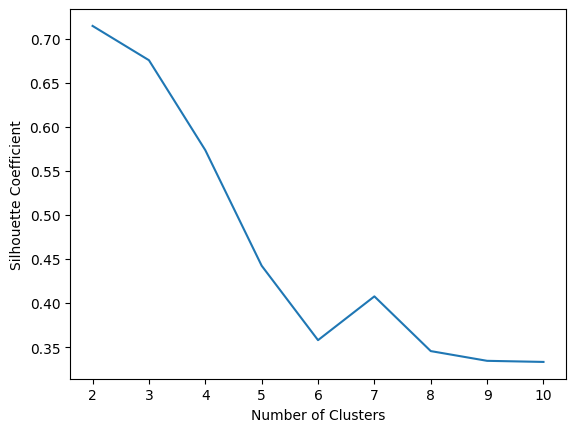

In [30]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()